In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

In [3]:
ds = xr.concat(datasets, dim='station')

# Bimonthly - select highest every 2 months
for independence

In [11]:
ds = ds.sel(station=[1, 10, 102, 103, 97])

status
ok    5
Name: count, dtype: int64


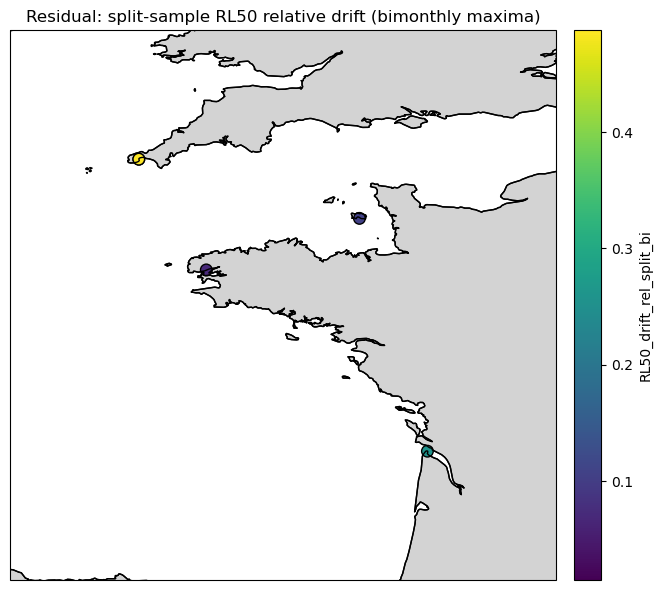

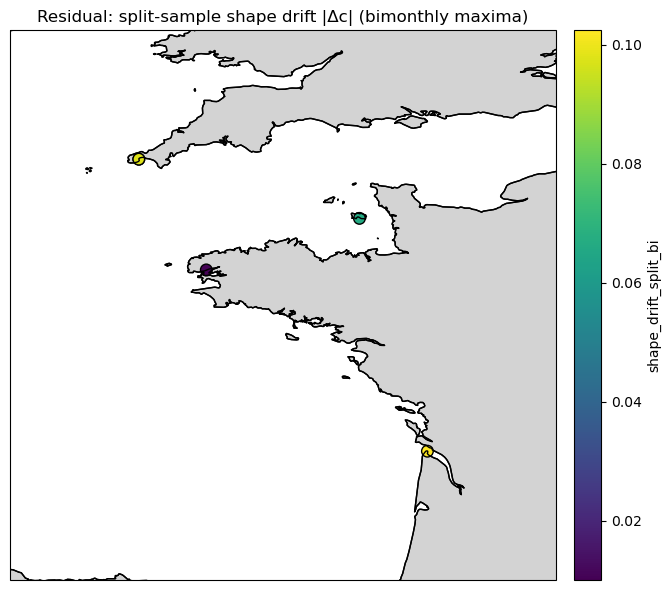

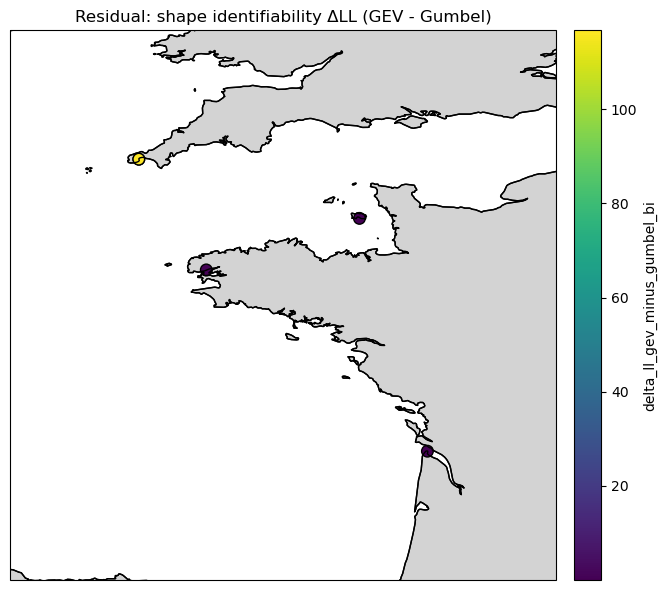

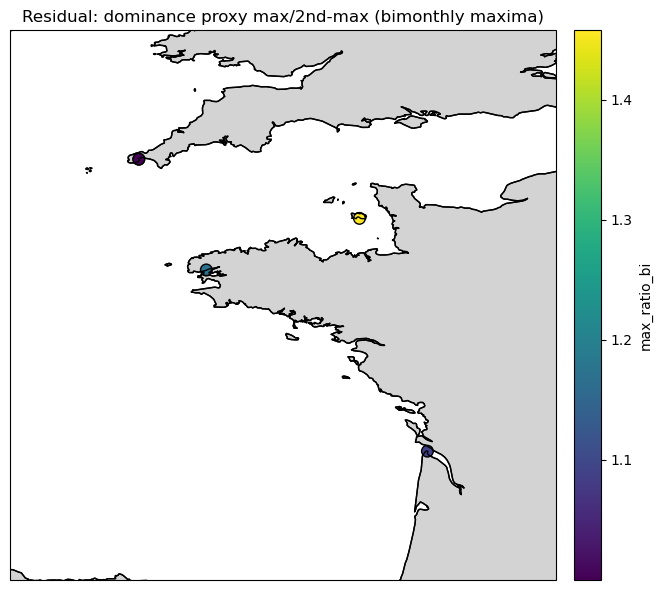

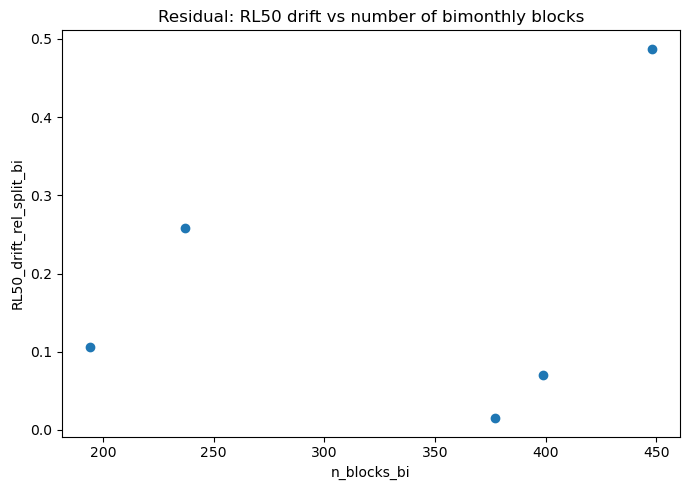

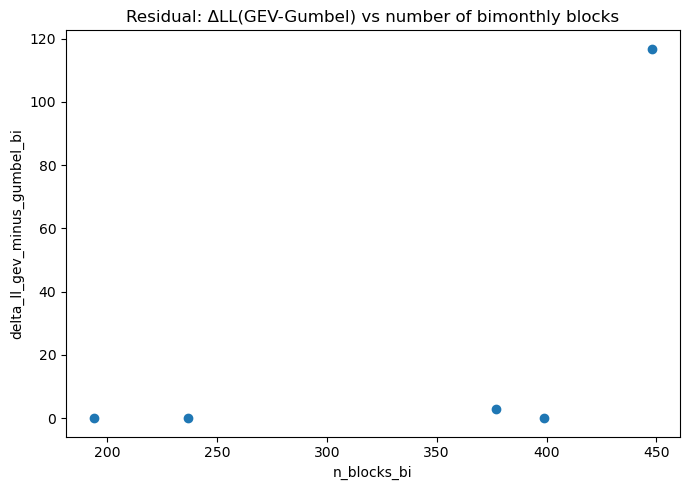

In [13]:
# GEV stability tests for ds["residual"] only (bimonthly maxima), with visuals
import numpy as np
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# --------------------------
# Utilities
# --------------------------
def infer_time_dim(ds, station_dim="station"):
    for cand in ["time", "valid_time", "date", "datetime"]:
        if cand in ds.dims or cand in ds.coords:
            return cand
    for c in ds.coords:
        try:
            if np.issubdtype(ds[c].dtype, np.datetime64):
                return c
        except Exception:
            pass
    dims = [d for d in ds.dims if d != station_dim]
    if not dims:
        raise ValueError("Could not infer a time dimension.")
    return dims[0]

def bimonthly_maxima(da, tdim, rule="2M"):
    da = da.where(np.isfinite(da), drop=True)
    return da.resample({tdim: rule}).max()

def gev_return_level(params, T, blocks_per_year=6):
    c, loc, scale = params
    p = 1.0 - 1.0/(blocks_per_year*T)
    return st.genextreme.ppf(p, c, loc=loc, scale=scale)

def empirical_return_level(x, T, blocks_per_year=6):
    x = np.sort(np.asarray(x))
    n = len(x)
    p = 1.0 - 1.0/(blocks_per_year*T)
    F = np.arange(1, n+1)/(n+1.0)
    return np.interp(p, F, x)

def gev_split_stability(x, T=50, blocks_per_year=6):
    x = np.asarray(x)
    n = len(x)
    if n < 30:
        return np.nan, np.nan

    x1 = x[:n//2]
    x2 = x[n//2:]

    try:
        p1 = st.genextreme.fit(x1)
        p2 = st.genextreme.fit(x2)
        pf = st.genextreme.fit(x)

        rl1 = gev_return_level(p1, T, blocks_per_year)
        rl2 = gev_return_level(p2, T, blocks_per_year)
        rlf = gev_return_level(pf, T, blocks_per_year)

        shape_drift = abs(p1[0] - p2[0])
        rl_drift_rel = abs(rl1 - rl2) / abs(rlf) if np.isfinite(rlf) and rlf != 0 else np.nan
        return shape_drift, rl_drift_rel
    except Exception:
        return np.nan, np.nan

def gev_shape_identifiability_delta_ll(x):
    x = np.asarray(x)
    try:
        c, loc, scale = st.genextreme.fit(x)
        ll_gev = np.sum(st.genextreme.logpdf(x, c, loc=loc, scale=scale))

        loc_g, scale_g = st.gumbel_r.fit(x)
        ll_gum = np.sum(st.gumbel_r.logpdf(x, loc=loc_g, scale=scale_g))

        return ll_gev - ll_gum
    except Exception:
        return np.nan

def dominance_proxy_max_ratio(x):
    x = np.sort(np.asarray(x))
    if len(x) < 10 or x[-2] == 0:
        return np.nan
    return x[-1] / x[-2]


# --------------------------
# Compute per-station stability for residual only
# --------------------------
station_dim = "station"
var_name = "residual"
resample_rule = "2M"
blocks_per_year = 6
T_list = (10, 20, 50)
T_split = 50
min_blocks = 20

if var_name not in ds.data_vars:
    raise ValueError("ds does not contain variable 'residual'.")

tdim = infer_time_dim(ds, station_dim=station_dim)
stations = ds[station_dim].values

rows = []
for s in stations:
    da = ds[var_name].sel({station_dim: s})
    try:
        da_bi = bimonthly_maxima(da, tdim, rule=resample_rule)
    except Exception:
        rows.append({"station": int(s), "status": "resample_failed"})
        continue

    x = np.asarray(da_bi.values).ravel()
    x = x[np.isfinite(x)]

    out = {"station": int(s), "n_blocks_bi": int(x.size)}

    if x.size < min_blocks:
        out["status"] = "too_few_blocks"
        rows.append(out)
        continue

    try:
        params = st.genextreme.fit(x)
        out["status"] = "ok"
        out["gev_c_bi"], out["gev_loc_bi"], out["gev_scale_bi"] = params
    except Exception:
        out["status"] = "fit_failed"
        rows.append(out)
        continue

    # Empirical vs fitted return levels
    for T in T_list:
        emp = empirical_return_level(x, T, blocks_per_year)
        gev = gev_return_level(params, T, blocks_per_year)
        out[f"RL{T}_emp_bi"] = emp
        out[f"RL{T}_gev_bi"] = gev
        out[f"RL{T}_absdiff_bi"] = gev - emp
        out[f"RL{T}_reldiff_bi"] = (gev - emp) / emp if emp != 0 else np.nan

    # Stability metrics
    shape_drift, rl_drift_rel = gev_split_stability(x, T=T_split, blocks_per_year=blocks_per_year)
    out["shape_drift_split_bi"] = shape_drift
    out[f"RL{T_split}_drift_rel_split_bi"] = rl_drift_rel
    out["delta_ll_gev_minus_gumbel_bi"] = gev_shape_identifiability_delta_ll(x)
    out["max_ratio_bi"] = dominance_proxy_max_ratio(x)

    rows.append(out)

residual_stability_df = pd.DataFrame(rows)

print(residual_stability_df["status"].value_counts(dropna=False))


# --------------------------
# Attach station lat/lon from ds (if available) for mapping
# --------------------------
if "station_latitude" in ds and "station_longitude" in ds:
    station_coords = (
        ds[["station_latitude", "station_longitude"]]
        .to_dataframe()
        .reset_index()
        .rename(columns={"station_latitude": "lat", "station_longitude": "lon"})
    )
    residual_stability_df = residual_stability_df.merge(
        station_coords[["station", "lat", "lon"]],
        on="station",
        how="left",
    )


# --------------------------
# Visualisations
# --------------------------
def plot_metric_map(df, metric_col, title, lat_col="lat", lon_col="lon", size=70):
    dfp = df.dropna(subset=[lat_col, lon_col, metric_col]).copy()

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=proj)

    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", zorder=0)
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

    pad = 2.0
    ax.set_extent(
        [dfp[lon_col].min()-pad, dfp[lon_col].max()+pad,
         dfp[lat_col].min()-pad, dfp[lat_col].max()+pad],
        crs=proj
    )

    sc = ax.scatter(
        dfp[lon_col], dfp[lat_col],
        c=pd.to_numeric(dfp[metric_col], errors="coerce"),
        s=size,
        transform=proj,
        edgecolor="k"
    )

    ax.set_title(title)
    cb = plt.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(metric_col)
    plt.tight_layout()
    plt.show()

def scatter_vs_blocks(df, metric_col, blocks_col="n_blocks_bi", title=None):
    dfp = df.dropna(subset=[blocks_col, metric_col]).copy()
    plt.figure(figsize=(7, 5))
    plt.scatter(dfp[blocks_col], dfp[metric_col])
    plt.xlabel(blocks_col)
    plt.ylabel(metric_col)
    plt.title(title or f"{metric_col} vs {blocks_col}")
    plt.tight_layout()
    plt.show()

# Maps (only if lat/lon were successfully merged)
if {"lat", "lon"}.issubset(residual_stability_df.columns):
    plot_metric_map(
        residual_stability_df, "RL50_drift_rel_split_bi",
        "Residual: split-sample RL50 relative drift (bimonthly maxima)"
    )
    plot_metric_map(
        residual_stability_df, "shape_drift_split_bi",
        "Residual: split-sample shape drift |Δc| (bimonthly maxima)"
    )
    plot_metric_map(
        residual_stability_df, "delta_ll_gev_minus_gumbel_bi",
        "Residual: shape identifiability ΔLL (GEV - Gumbel)"
    )
    plot_metric_map(
        residual_stability_df, "max_ratio_bi",
        "Residual: dominance proxy max/2nd-max (bimonthly maxima)"
    )
else:
    print("No lat/lon found in residual_stability_df; skipping maps.")

# Confounder checks
scatter_vs_blocks(
    residual_stability_df, "RL50_drift_rel_split_bi",
    title="Residual: RL50 drift vs number of bimonthly blocks"
)
scatter_vs_blocks(
    residual_stability_df, "delta_ll_gev_minus_gumbel_bi",
    title="Residual: ΔLL(GEV-Gumbel) vs number of bimonthly blocks"
)
